# **Black Box Algorithm vs. Interpretable Model**

## A Demonstration of Reproducible Models on Complex Datasets

Created by **Rae Chipera**

**Jaxorik AI Research Group,** registered in SAM.GOV for federal contracting
- UEID: K8ENCCGZ2M13
- Cage Code: 11X70
- Disaster Response registry: Active
- Eligible for WOSB and SDVOSB set-asides

**FOR CONTRACT INQUIRIES:** govinquiries@jaxorik.com

------------------------------------------------

### Overview
This demonstration compares black box deep learning approaches with transparent machine learning models for satellite imagery anomaly detection. Using realistic synthetic multispectral data, we show that interpretable models can match or exceed black box performance while providing critical explainability for high-stakes decision-making.

### Why This Matters for Defense & Disaster Response
In mission-critical applications, understanding *why* a model flagged something as anomalous is as important as the detection itself. Transparent models enable:
- **Operational trust**: Analysts can validate detections before taking action
- **Reduced false positives**: Understanding feature contributions helps filter noise
- **Accountability**: Clear decision paths for after-action review
- **Rapid adaptation**: Interpretable rules can be adjusted for new threat types

### What's Demonstrated
- **Realistic satellite imagery simulation**: 12 spectral/spatial features across multiple bands (RGB, NIR, SWIR, Thermal, computed indices)
- **Defense-relevant anomaly types**: New construction, camouflaged structures, fires, flooding, vehicle concentrations
- **Three model approaches**: Autoencoder (black box), Decision Trees, and Reservoir Computing (both transparent)
- **Performance comparison**: Accuracy, ROC-AUC, and per-anomaly-type detection rates
- **Explainability analysis**: Side-by-side comparison of what each model can tell you about its decisions

### Results
The transparent models achieved 99%+ accuracy with perfect AUC scores, outperforming the black box autoencoder (84% accuracy) while providing full explainability.

In [86]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter, sobel
from scipy.signal import convolve2d

np.random.seed(42)

def generate_realistic_satellite_data(grid_size=64, noise_level=0.05):
    """
    Generate realistic synthetic satellite imagery with multiple spectral bands
    and spatially-structured anomalies relevant to defense and disaster response.
    
    Spectral Bands (10 total):
    - RGB: Red, Green, Blue (visible spectrum)
    - NIR: Near-Infrared
    - SWIR1, SWIR2: Short-Wave Infrared (penetrates haze, detects moisture)
    - TIR1, TIR2: Thermal Infrared (heat detection)
    - NDVI: Normalized Difference Vegetation Index
    - NDWI: Normalized Difference Water Index
    
    Anomaly Types:
    1. New Construction: High reflectance, geometric edges, low vegetation
    2. Camouflaged Structures: Visible/NIR mismatch (fake vegetation)
    3. Fires: Extreme thermal signature with smoke (low visible, high thermal)
    4. Flooding: Water signature in normally dry areas
    5. Vehicle Concentrations: Small bright spots with thermal signatures
    """
    
    # === STEP 1: Generate base terrain with spatial structure ===
    
    # Create spatially correlated base terrain using multiple octaves of noise
    def generate_perlin_like(shape, scale=10):
        """Simple multi-scale noise for terrain generation"""
        result = np.zeros(shape)
        for octave in range(4):
            freq = 2 ** octave
            noise = np.random.randn(shape[0] // freq + 1, shape[1] // freq + 1)
            noise = gaussian_filter(noise, sigma=1)
            # Upsample
            from scipy.ndimage import zoom
            noise_scaled = zoom(noise, freq, order=1)[:shape[0], :shape[1]]
            result += noise_scaled / (2 ** octave)
        return (result - result.min()) / (result.max() - result.min())
    
    terrain_elevation = generate_perlin_like((grid_size, grid_size))
    terrain_type = generate_perlin_like((grid_size, grid_size), scale=5)
    
    # Classify terrain: water (0-0.3), vegetation (0.3-0.6), urban/bare (0.6-1.0)
    water_mask = terrain_type < 0.3
    veg_mask = (terrain_type >= 0.3) & (terrain_type < 0.6)
    urban_mask = terrain_type >= 0.6
    
    # === STEP 2: Generate spectral bands based on terrain ===
    
    # Initialize bands
    n_pixels = grid_size * grid_size
    
    # Visible bands (RGB)
    red = np.zeros((grid_size, grid_size))
    green = np.zeros((grid_size, grid_size))
    blue = np.zeros((grid_size, grid_size))
    
    # Water: low red, moderate green/blue
    red[water_mask] = 0.1 + 0.1 * np.random.random(water_mask.sum())
    green[water_mask] = 0.2 + 0.15 * np.random.random(water_mask.sum())
    blue[water_mask] = 0.3 + 0.2 * np.random.random(water_mask.sum())
    
    # Vegetation: low red/blue, high green
    red[veg_mask] = 0.15 + 0.1 * np.random.random(veg_mask.sum())
    green[veg_mask] = 0.4 + 0.2 * np.random.random(veg_mask.sum())
    blue[veg_mask] = 0.1 + 0.1 * np.random.random(veg_mask.sum())
    
    # Urban/bare: moderate all channels
    red[urban_mask] = 0.3 + 0.2 * np.random.random(urban_mask.sum())
    green[urban_mask] = 0.25 + 0.2 * np.random.random(urban_mask.sum())
    blue[urban_mask] = 0.2 + 0.15 * np.random.random(urban_mask.sum())
    
    # Smooth spatial transitions
    red = gaussian_filter(red, sigma=1.5)
    green = gaussian_filter(green, sigma=1.5)
    blue = gaussian_filter(blue, sigma=1.5)
    
    # NIR (Near-Infrared) - vegetation reflects strongly
    nir = np.zeros((grid_size, grid_size))
    nir[water_mask] = 0.05 + 0.05 * np.random.random(water_mask.sum())
    nir[veg_mask] = 0.6 + 0.2 * np.random.random(veg_mask.sum())
    nir[urban_mask] = 0.2 + 0.15 * np.random.random(urban_mask.sum())
    nir = gaussian_filter(nir, sigma=1.5)
    
    # SWIR bands (Short-Wave Infrared) - moisture detection
    swir1 = nir * 0.7 + 0.1 * np.random.random((grid_size, grid_size))
    swir2 = nir * 0.6 + 0.1 * np.random.random((grid_size, grid_size))
    swir1[water_mask] *= 0.3  # Water absorbs SWIR
    swir2[water_mask] *= 0.3
    
    # Thermal bands (heat signature)
    tir1 = 0.3 + 0.2 * terrain_elevation + 0.1 * np.random.random((grid_size, grid_size))
    tir2 = tir1 * 0.9 + 0.05 * np.random.random((grid_size, grid_size))
    tir1[urban_mask] += 0.15  # Urban heat island effect
    tir2[urban_mask] += 0.15
    
    # Computed indices
    ndvi = (nir - red) / (nir + red + 1e-8)  # Vegetation index
    ndwi = (green - nir) / (green + nir + 1e-8)  # Water index
    
    # === STEP 3: Add edge/texture features ===
    
    # Edge magnitude from visible bands
    edge_x = sobel(green, axis=0)
    edge_y = sobel(green, axis=1)
    edge_magnitude = np.sqrt(edge_x**2 + edge_y**2)
    edge_magnitude = (edge_magnitude - edge_magnitude.min()) / (edge_magnitude.max() - edge_magnitude.min() + 1e-8)
    
    # Local texture variance (using a sliding window approximation)
    texture_variance = gaussian_filter(green**2, sigma=2) - gaussian_filter(green, sigma=2)**2
    texture_variance = (texture_variance - texture_variance.min()) / (texture_variance.max() - texture_variance.min() + 1e-8)
    
    # === STEP 4: Inject realistic anomalies ===
    
    anomaly_mask = np.zeros((grid_size, grid_size), dtype=bool)
    anomaly_types = np.zeros((grid_size, grid_size), dtype=int)
    
    # Anomaly 1: New Construction (5-8 instances)
    n_construction = np.random.randint(5, 9)
    for _ in range(n_construction):
        # Place in urban or bare areas
        valid_locations = np.argwhere(urban_mask)
        if len(valid_locations) > 0:
            center = valid_locations[np.random.randint(len(valid_locations))]
            size = np.random.randint(3, 7)
            y, x = center
            y_slice = slice(max(0, y-size), min(grid_size, y+size))
            x_slice = slice(max(0, x-size), min(grid_size, x+size))
            
            # Create rectangular structure
            structure = np.ones((y_slice.stop - y_slice.start, x_slice.stop - x_slice.start))
            
            # High reflectance in visible/SWIR, geometric edges, no vegetation
            red[y_slice, x_slice] = np.maximum(red[y_slice, x_slice], 0.6 + 0.1 * structure)
            green[y_slice, x_slice] = np.maximum(green[y_slice, x_slice], 0.55 + 0.1 * structure)
            blue[y_slice, x_slice] = np.maximum(blue[y_slice, x_slice], 0.5 + 0.1 * structure)
            nir[y_slice, x_slice] = np.minimum(nir[y_slice, x_slice], 0.2)  # No vegetation
            ndvi[y_slice, x_slice] = -0.2
            edge_magnitude[y_slice, x_slice] = 0.9  # Sharp edges
            
            anomaly_mask[y_slice, x_slice] = True
            anomaly_types[y_slice, x_slice] = 1
    
    # Anomaly 2: Camouflaged Structures (3-5 instances)
    n_camouflage = np.random.randint(3, 6)
    for _ in range(n_camouflage):
        valid_locations = np.argwhere(veg_mask & ~anomaly_mask)
        if len(valid_locations) > 0:
            center = valid_locations[np.random.randint(len(valid_locations))]
            size = np.random.randint(2, 5)
            y, x = center
            y_slice = slice(max(0, y-size), min(grid_size, y+size))
            x_slice = slice(max(0, x-size), min(grid_size, x+size))
            
            # Visible looks like vegetation, but NIR is wrong
            green[y_slice, x_slice] = 0.5  # Painted green
            red[y_slice, x_slice] = 0.15
            nir[y_slice, x_slice] = 0.25  # But NIR reveals it's not real vegetation
            ndvi[y_slice, x_slice] = 0.1  # Abnormally low for "vegetation"
            
            anomaly_mask[y_slice, x_slice] = True
            anomaly_types[y_slice, x_slice] = 2
    
    # Anomaly 3: Fires (2-4 instances)
    n_fires = np.random.randint(2, 5)
    for _ in range(n_fires):
        valid_locations = np.argwhere((veg_mask | urban_mask) & ~anomaly_mask)
        if len(valid_locations) > 0:
            center = valid_locations[np.random.randint(len(valid_locations))]
            size = np.random.randint(2, 4)
            y, x = center
            y_slice = slice(max(0, y-size), min(grid_size, y+size))
            x_slice = slice(max(0, x-size), min(grid_size, x+size))
            
            # Extreme thermal signature
            tir1[y_slice, x_slice] = 0.9 + 0.1 * np.random.random()
            tir2[y_slice, x_slice] = 0.85 + 0.1 * np.random.random()
            
            # Smoke reduces visible reflectance
            red[y_slice, x_slice] *= 0.5
            green[y_slice, x_slice] *= 0.5
            blue[y_slice, x_slice] *= 0.5
            
            # Destroyed vegetation
            nir[y_slice, x_slice] = 0.1
            ndvi[y_slice, x_slice] = -0.3
            
            anomaly_mask[y_slice, x_slice] = True
            anomaly_types[y_slice, x_slice] = 3
    
    # Anomaly 4: Flooding (2-3 instances)
    n_floods = np.random.randint(2, 4)
    for _ in range(n_floods):
        valid_locations = np.argwhere((veg_mask | urban_mask) & ~anomaly_mask)
        if len(valid_locations) > 0:
            center = valid_locations[np.random.randint(len(valid_locations))]
            size = np.random.randint(4, 8)
            y, x = center
            y_slice = slice(max(0, y-size), min(grid_size, y+size))
            x_slice = slice(max(0, x-size), min(grid_size, x+size))
            
            # Water signature in areas that should be dry
            red[y_slice, x_slice] = 0.1
            green[y_slice, x_slice] = 0.2
            blue[y_slice, x_slice] = 0.35
            nir[y_slice, x_slice] = 0.05
            swir1[y_slice, x_slice] = 0.02
            swir2[y_slice, x_slice] = 0.02
            ndwi[y_slice, x_slice] = 0.5  # High water content
            ndvi[y_slice, x_slice] = -0.4
            
            anomaly_mask[y_slice, x_slice] = True
            anomaly_types[y_slice, x_slice] = 4
    
    # Anomaly 5: Vehicle Concentrations (3-6 instances)
    n_vehicles = np.random.randint(3, 7)
    for _ in range(n_vehicles):
        valid_locations = np.argwhere(urban_mask & ~anomaly_mask)
        if len(valid_locations) > 0:
            center = valid_locations[np.random.randint(len(valid_locations))]
            # Small cluster of 1-2 pixel vehicles
            n_veh = np.random.randint(3, 8)
            for _ in range(n_veh):
                offset_y = np.random.randint(-3, 4)
                offset_x = np.random.randint(-3, 4)
                vy, vx = center[0] + offset_y, center[1] + offset_x
                if 0 <= vy < grid_size and 0 <= vx < grid_size:
                    # Bright in visible, moderate thermal
                    red[vy, vx] = 0.7
                    green[vy, vx] = 0.65
                    blue[vy, vx] = 0.6
                    tir1[vy, vx] += 0.2
                    tir2[vy, vx] += 0.2
                    
                    anomaly_mask[vy, vx] = True
                    anomaly_types[vy, vx] = 5
    
    # === STEP 5: Add realistic noise and atmospheric effects ===
    
    # Sensor noise (varies by band)
    red += noise_level * np.random.randn(grid_size, grid_size)
    green += noise_level * np.random.randn(grid_size, grid_size)
    blue += noise_level * np.random.randn(grid_size, grid_size)
    nir += noise_level * 0.8 * np.random.randn(grid_size, grid_size)
    swir1 += noise_level * 1.2 * np.random.randn(grid_size, grid_size)
    swir2 += noise_level * 1.2 * np.random.randn(grid_size, grid_size)
    tir1 += noise_level * 0.5 * np.random.randn(grid_size, grid_size)
    tir2 += noise_level * 0.5 * np.random.randn(grid_size, grid_size)
    
    # Atmospheric haze (affects visible more than IR)
    haze_pattern = generate_perlin_like((grid_size, grid_size), scale=20) * 0.1
    red += haze_pattern
    green += haze_pattern * 0.8
    blue += haze_pattern * 0.6
    
    # Clip all values to valid range
    red = np.clip(red, 0, 1)
    green = np.clip(green, 0, 1)
    blue = np.clip(blue, 0, 1)
    nir = np.clip(nir, 0, 1)
    swir1 = np.clip(swir1, 0, 1)
    swir2 = np.clip(swir2, 0, 1)
    tir1 = np.clip(tir1, 0, 1)
    tir2 = np.clip(tir2, 0, 1)
    ndvi = np.clip(ndvi, -1, 1)
    ndwi = np.clip(ndwi, -1, 1)
    
    # === STEP 6: Flatten to dataframe ===
    
    x_coords = np.repeat(np.arange(grid_size), grid_size)
    y_coords = np.tile(np.arange(grid_size), grid_size)
    
    df = pd.DataFrame({
        'x': x_coords,
        'y': y_coords,
        'red': red.flatten(),
        'green': green.flatten(),
        'blue': blue.flatten(),
        'nir': nir.flatten(),
        'swir1': swir1.flatten(),
        'swir2': swir2.flatten(),
        'tir1': tir1.flatten(),
        'tir2': tir2.flatten(),
        'ndvi': ndvi.flatten(),
        'ndwi': ndwi.flatten(),
        'edge_magnitude': edge_magnitude.flatten(),
        'texture_variance': texture_variance.flatten(),
        'anomaly': anomaly_mask.flatten().astype(int),
        'anomaly_type': anomaly_types.flatten()
    })
    
    # Create feature matrix
    feature_names = ['red', 'green', 'blue', 'nir', 'swir1', 'swir2', 
                     'tir1', 'tir2', 'ndvi', 'ndwi', 'edge_magnitude', 'texture_variance']
    X = df[feature_names].values
    y = df['anomaly'].values
    
    return df, X, y, feature_names

# Test the generator
if __name__ == "__main__":
    df, X, y, feature_names = generate_realistic_satellite_data(grid_size=64)
    print(f"Generated {len(df)} pixels")
    print(f"Features: {feature_names}")
    print(f"Anomalies: {y.sum()} ({100*y.sum()/len(y):.1f}%)")
    print(f"\nAnomaly type breakdown:")
    for i in range(1, 6):
        count = (df['anomaly_type'] == i).sum()
        types = ['Construction', 'Camouflage', 'Fire', 'Flood', 'Vehicles']
        print(f"  {types[i-1]}: {count} pixels")

Generated 4096 pixels
Features: ['red', 'green', 'blue', 'nir', 'swir1', 'swir2', 'tir1', 'tir2', 'ndvi', 'ndwi', 'edge_magnitude', 'texture_variance']
Anomalies: 1031 (25.2%)

Anomaly type breakdown:
  Construction: 423 pixels
  Camouflage: 180 pixels
  Fire: 128 pixels
  Flood: 284 pixels
  Vehicles: 16 pixels


In [120]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_realistic_satellite_data(df, title, predictions=None, ax=None, show_type=False):
    """
    Visualize realistic satellite data as a grid with anomalies highlighted.
    
    Parameters:
    - df: DataFrame containing x, y coordinates and anomaly labels
    - title: Plot title
    - predictions: Optional array of predicted anomalies
    - ax: Optional matplotlib axis to plot on
    - show_type: If True, color by anomaly type instead of prediction accuracy
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    grid_size_x = df['x'].max() + 1
    grid_size_y = df['y'].max() + 1
    
    if show_type and 'anomaly_type' in df.columns:
        # Show anomaly types with distinct colors
        grid = np.zeros((grid_size_y, grid_size_x, 3))
        type_colors = {
            0: [0.2, 0.2, 0.2],      # Normal - dark gray
            1: [1.0, 0.5, 0.0],       # Construction - orange
            2: [0.6, 0.0, 0.6],       # Camouflage - purple
            3: [1.0, 0.0, 0.0],       # Fire - red
            4: [0.0, 0.4, 0.8],       # Flood - blue
            5: [1.0, 1.0, 0.0]        # Vehicles - yellow
        }
        
        for idx, row in df.iterrows():
            x, y = int(row['x']), int(row['y'])
            if 0 <= x < grid_size_x and 0 <= y < grid_size_y:
                anomaly_type = int(row['anomaly_type'])
                grid[y, x] = type_colors.get(anomaly_type, [0.5, 0.5, 0.5])
        
        ax.imshow(grid, interpolation='nearest')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=type_colors[0], label='Normal'),
            Patch(facecolor=type_colors[1], label='Construction'),
            Patch(facecolor=type_colors[2], label='Camouflage'),
            Patch(facecolor=type_colors[3], label='Fire'),
            Patch(facecolor=type_colors[4], label='Flood'),
            Patch(facecolor=type_colors[5], label='Vehicles')
        ]
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
        
    elif predictions is None:
        # Just show ground truth (anomaly vs normal)
        grid = np.zeros((grid_size, grid_size, 3))
        for idx, row in df.iterrows():
            x, y = int(row['x']), int(row['y'])
            if 0 <= x < grid_size_x and 0 <= y < grid_size_y:
                if row['anomaly'] == 1:
                    grid[y, x] = [1, 0, 0]  # Red for anomalies
                else:
                    grid[y, x] = [0.8, 0.8, 0.8]  # Light gray for normal
        
        ax.imshow(grid, interpolation='nearest')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        
    else:
        # Show predictions vs ground truth
        grid = np.zeros((grid_size_y, grid_size_x, 3))
        for idx, row in df.iterrows():
            x, y = int(row['x']), int(row['y'])
            if 0 <= x < grid_size_x and 0 <= y < grid_size_y:
                true_label = row['anomaly']
                pred_label = predictions[idx]
                
                if true_label == 1 and pred_label == 1:
                    grid[y, x] = [0, 0.8, 0]  # Green for true positives
                elif true_label == 0 and pred_label == 1:
                    grid[y, x] = [1, 0.8, 0]  # Yellow for false positives
                elif true_label == 1 and pred_label == 0:
                    grid[y, x] = [0.8, 0, 0.8]  # Purple for false negatives
                else:
                    grid[y, x] = [0, 0.6, 0.8]  # Blue for true negatives
        
        ax.imshow(grid, interpolation='nearest')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
    
    return ax


def plot_spectral_bands(df, sample_idx=None, figsize=(20, 10)):
    """
    Visualize individual spectral bands and computed indices.
    
    Parameters:
    - df: DataFrame with satellite data
    - sample_idx: Optional index to highlight a specific pixel
    - figsize: Figure size
    """
    # Get the original grid dimensions from the x,y coordinates
    grid_size_x = df['x'].max() + 1
    grid_size_y = df['y'].max() + 1
    
    bands = ['red', 'green', 'blue', 'nir', 'swir1', 'swir2', 
             'tir1', 'tir2', 'ndvi', 'ndwi', 'edge_magnitude', 'texture_variance']
    
    fig, axes = plt.subplots(3, 4, figsize=figsize)
    axes = axes.flatten()
    
    for i, band in enumerate(bands):
        # Create empty grid and fill with available data
        data = np.full((grid_size_y, grid_size_x), np.nan)
        for idx, row in df.iterrows():
            x, y = int(row['x']), int(row['y'])
            data[y, x] = row[band]
        
        im = axes[i].imshow(data, cmap='viridis', interpolation='nearest')
        axes[i].set_title(band.upper(), fontsize=10)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        
        # Highlight specific pixel if requested
        if sample_idx is not None:
            x = df.loc[sample_idx, 'x']
            y = df.loc[sample_idx, 'y']
            axes[i].plot(x, y, 'r*', markersize=10)
        
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    return fig


def plot_rgb_composite(df, figsize=(12, 10)):
    """
    Create RGB composite and false-color composites commonly used in remote sensing.
    
    Parameters:
    - df: DataFrame with satellite data
    - figsize: Figure size
    """
    grid_size_x = df['x'].max() + 1
    grid_size_y = df['y'].max() + 1
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Helper function to create grid from dataframe
    def create_band_grid(df, band_name):
        grid = np.full((grid_size_y, grid_size_x), np.nan)
        for idx, row in df.iterrows():
            x, y = int(row['x']), int(row['y'])
            grid[y, x] = row[band_name]
        return grid
    
    # True color (RGB)
    rgb = np.dstack([
        create_band_grid(df, 'red'),
        create_band_grid(df, 'green'),
        create_band_grid(df, 'blue')
    ])
    rgb = np.clip(rgb, 0, 1)
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title('True Color (RGB)')
    axes[0, 0].axis('off')
    
    # False color (NIR-R-G) - vegetation appears red
    false_color = np.dstack([
        create_band_grid(df, 'nir'),
        create_band_grid(df, 'red'),
        create_band_grid(df, 'green')
    ])
    false_color = np.clip(false_color, 0, 1)
    axes[0, 1].imshow(false_color)
    axes[0, 1].set_title('False Color (NIR-R-G)')
    axes[0, 1].axis('off')
    
    # SWIR composite (SWIR2-SWIR1-NIR) - good for geology and urban
    swir_composite = np.dstack([
        create_band_grid(df, 'swir2'),
        create_band_grid(df, 'swir1'),
        create_band_grid(df, 'nir')
    ])
    swir_composite = np.clip(swir_composite, 0, 1)
    axes[1, 0].imshow(swir_composite)
    axes[1, 0].set_title('SWIR Composite')
    axes[1, 0].axis('off')
    
    # Thermal
    thermal = create_band_grid(df, 'tir1')
    im = axes[1, 1].imshow(thermal, cmap='hot', interpolation='nearest')
    axes[1, 1].set_title('Thermal (TIR1)')
    axes[1, 1].axis('off')
    plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    return fig


def plot_anomaly_detection_details(df, y_pred, y_test, figsize=(20, 12)):
    """
    Create comprehensive visualization of anomaly detection results.
    
    Parameters:
    - df: DataFrame with satellite data (test set)
    - y_pred: Predicted anomaly labels
    - y_test: True anomaly labels
    - figsize: Figure size
    """
    grid_size_x = df['x'].max() + 1
    grid_size_y = df['y'].max() + 1
    
    # Helper function to create grid from dataframe
    def create_band_grid(df, band_name):
        grid = np.full((grid_size_y, grid_size_x), np.nan)
        for idx, row in df.iterrows():
            x, y = int(row['x']), int(row['y'])
            grid[y, x] = row[band_name]
        return grid
    
    fig = plt.figure(figsize=figsize)
    
    # Create a 3x3 grid
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Row 1: RGB, Ground Truth, Predictions
    ax1 = fig.add_subplot(gs[0, 0])
    rgb = np.dstack([
        create_band_grid(df, 'red'),
        create_band_grid(df, 'green'),
        create_band_grid(df, 'blue')
    ])
    rgb = np.clip(rgb, 0, 1)
    ax1.imshow(rgb)
    ax1.set_title('RGB Composite')
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[0, 1])
    plot_realistic_satellite_data(df, 'Ground Truth by Type', ax=ax2, show_type=True)
    
    ax3 = fig.add_subplot(gs[0, 2])
    plot_realistic_satellite_data(df, 'Model Predictions', predictions=y_pred, ax=ax3)
    
    # Row 2: Key spectral bands
    ax4 = fig.add_subplot(gs[1, 0])
    ndvi = create_band_grid(df, 'ndvi')
    im = ax4.imshow(ndvi, cmap='RdYlGn', interpolation='nearest', vmin=-1, vmax=1)
    ax4.set_title('NDVI (Vegetation Index)')
    ax4.axis('off')
    plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
    
    ax5 = fig.add_subplot(gs[1, 1])
    thermal = create_band_grid(df, 'tir1')
    im = ax5.imshow(thermal, cmap='hot', interpolation='nearest')
    ax5.set_title('Thermal (TIR1)')
    ax5.axis('off')
    plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)
    
    ax6 = fig.add_subplot(gs[1, 2])
    edges = create_band_grid(df, 'edge_magnitude')
    im = ax6.imshow(edges, cmap='gray', interpolation='nearest')
    ax6.set_title('Edge Magnitude')
    ax6.axis('off')
    plt.colorbar(im, ax=ax6, fraction=0.046, pad=0.04)
    
    # Row 3: Analysis plots
    ax7 = fig.add_subplot(gs[2, 0])
    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax7)
    ax7.set_xlabel('Predicted')
    ax7.set_ylabel('Actual')
    ax7.set_title('Confusion Matrix')
    ax7.set_xticklabels(['Normal', 'Anomaly'])
    ax7.set_yticklabels(['Normal', 'Anomaly'])
    
    ax8 = fig.add_subplot(gs[2, 1])
    # Per-type detection rates
    if 'anomaly_type' in df.columns:
        type_names = ['Construction', 'Camouflage', 'Fire', 'Flood', 'Vehicles']
        detection_rates = []
        
        for i in range(1, 6):
            type_mask = df['anomaly_type'].values == i
            if type_mask.sum() > 0:
                detected = (y_pred[type_mask] == 1).sum()
                rate = detected / type_mask.sum()
                detection_rates.append(rate)
            else:
                detection_rates.append(0)
        
        ax8.bar(type_names, detection_rates, color='steelblue')
        ax8.set_ylabel('Detection Rate')
        ax8.set_title('Detection Rate by Anomaly Type')
        ax8.set_ylim(0, 1.1)
        ax8.tick_params(axis='x', rotation=45)
        
        for i, rate in enumerate(detection_rates):
            ax8.text(i, rate + 0.02, f'{rate:.2f}', ha='center', fontsize=9)
    
    ax9 = fig.add_subplot(gs[2, 2])
    # Class balance
    true_counts = [len(y_test) - y_test.sum(), y_test.sum()]
    pred_counts = [len(y_pred) - y_pred.sum(), y_pred.sum()]
    
    x = np.arange(2)
    width = 0.35
    ax9.bar(x - width/2, true_counts, width, label='Ground Truth', color='lightblue')
    ax9.bar(x + width/2, pred_counts, width, label='Predicted', color='coral')
    ax9.set_ylabel('Count')
    ax9.set_title('Class Distribution')
    ax9.set_xticks(x)
    ax9.set_xticklabels(['Normal', 'Anomaly'])
    ax9.legend()
    
    return fig

## **AUTOENCODER (Black Box Model)**

In [95]:
# Function to build and train an autoencoder for anomaly detection (BLACK BOX MODEL)

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import Ridge

tf.random.set_seed(42)

def build_black_box(X_train, X_test, y_test, scaler = None):
    """
    Build and train black box autoencoder for anomaly detection.
    Returns the model, predictions, and reconstruction errors.
    """
    # Scale the data
    if scaler is None:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
    else:
        X_train_scaled = scaler.transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    # Define the input dimension
    input_dim = X_train.shape[1]

    # Define the encoder
    encoding_dim = 2 # Compressed representation size

    # Build the autoencoder black box model
    input_layer = Input(shape = (input_dim,))

    # Encoder layers
    encoded = Dense(8, activation = 'relu')(input_layer) # ReLU is a traditionally used activation function
    decoded = Dense(input_dim, activation = 'sigmoid')(encoded) # Sigmoid is traditionally used activation function

    # Autoencoder model
    autoencoder = Model(inputs = input_layer, outputs = decoded)

    # Separate encoder model for visualization
    encoder = Model(inputs=input_layer, outputs=encoded)

    # Compile the model
    autoencoder.compile(optimizer = 'adam', loss = 'mse') # Adam optimization and mean squard error

    # Train the model
    early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights=True)
    history = autoencoder.fit(
        X_train_scaled, X_train_scaled,
        epochs = 100,
        batch_size = 32,
        shuffle = True,
        validation_split = 0.2,
        callbacks = [early_stopping],
        verbose = 0
    )

    # Get reconstruction error on test set
    X_test_pred = autoencoder.predict(X_test_scaled)
    mse = np.mean(np.square(X_test_scaled - X_test_pred), axis = 1)

    # Find threshold for anomaly detection
    # Here we will use percentile-based approach, but could use other methods.
    threshold = np.percentile(mse, 95) # Assume top 5% are anomalous

    # Make predictions based on reconstruction error
    y_pred = (mse > threshold).astype(int)

    # Calculate accuracy
    accuracy = np.mean(y_pred == y_test)

    return autoencoder, encoder, y_pred, mse, threshold, accuracy, scaler, history    

## **DECISION TREE (Transparent Model)**

In [98]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Function to train and evaluate transparent model (Decision Tree)
def train_transparent_model(X_train, y_train, X_test, y_test, feature_names):
    """
    Train a transparent decision tree model.
    Returns the model, predictions on test data, and tree visualization.
    """
    # Create a decision tree classifier
    model = DecisionTreeClassifier(
        max_depth=4, # Limit tree depth for interpretability
        random_state = 42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = model.score(X_test, y_test)

    return model, y_pred, accuracy

In [100]:
# Function to explain the transparent model prediction for a sample
def explain_transparent_prediction(model, X_sample, feature_names):
    """
    Trace the decision path for a sample through the decision tree
    Returns a list of decision steps
    """
    # Get the decision path
    decision_path = model.decision_path(X_sample.reshape(1, -1))

    # Get the node feature indices, thresholds, and children
    n_nodes = model.tree_.node_count
    feature = model.tree_.feature
    threshold = model.tree_.threshold

    # Get leaf value (prediction)
    leaf_id = model.apply(X_sample.reshape(1, -1))[0]
    leaf_value = model.tree_.value[leaf_id][0]
    prediction = np.argmax(leaf_value)

    # Trace the path
    node_index = 0
    path = []

    while feature[node_index] != -2: # -2 indicates a leaf node
        if X_sample[feature[node_index]] <= threshold[node_index]:
            path.append(f"{feature_names[feature[node_index]]} <= {threshold[node_index]:.2f} ✓")
            node_index = model.tree_.children_left[node_index]
        else:
            path.append(f"{feature_names[feature[node_index]]} > {threshold[node_index]:.2f} ✓")
            node_index = model.tree_.children_right[node_index]

    path.append(f"Prediction: {'ANOMALY' if prediction == 1 else 'NORMAL'}")

    return path

## **RESERVOIR COMPUTING (Internet-Free Model)**

In [103]:
# Reservoir computing implementation

class ReservoirComputing:
    def __init__(self, n_inputs, n_reservoir=200, spectral_radius=0.95, sparsity=0.1,
                 leak_rate = 0.7, noise=0.001, random_state=42):
        """
        Initialize a Reservoir Computing model.

        Parameters:
        - n_inputs: Numner of input features
        - n_reservoir: Number of nodes (size) of the reservoir
        - spectral_radius: Radius of the reservoir weights (usually less than 1)
        - sparsity: Sparsity of the reservoir weights
        - leak_rate: Leak rate of the reservoir (usually between 0.3 and 0.9)
        - noise: Amount of noise added to the reservoir state
        - random_state: Random seed for reproducibility
        """
        self.n_inputs = n_inputs
        self.n_reservoir = n_reservoir
        self.spectral_radius = spectral_radius
        self.sparsity = sparsity
        self.leak_rate = leak_rate
        self.noise = noise

        if random_state is not None:
            np.random.seed(random_state)

        # Initialize input weights (W_in)
        self.W_in = np.random.randn(n_reservoir, n_inputs) * 0.1

        # Initialize reservoir weights (W)
        # Create sparse random matrix
        W = np.random.rand(n_reservoir, n_reservoir) - 0.5
        # Make it sparse
        W[np.random.rand(*W.shape) > sparsity] = 0
        # Compute the spectral radius
        radius = np.max(np.abs(np.linalg.eigvals(W)))
        # Rescale to desired spectral radius
        self.W = W * (spectral_radius / radius) if radius > 0 else W

        # Initialize readout with Ridge regeression
        self.readout = Ridge(alpha=1e-6)

        # For visualization and interpretation
        self.feature_weights = None
        self.reservoir_weights = None

    def _update_reservoir(self, x, r):
        """
        Updates the reservoir state.

        Parameters:
        - x: Input data point
        - r: Current reservoir state

        Returns: update reservoir state
        """
        # Compute new reservoir state
        r_new = np.tanh(np.dot(self.W_in, x) + np.dot(self.W, r)) # tanh this time because why not use all the typical functions?
        # Add noise
        r_new += self.noise * np.random.randn(self.n_reservoir)
        r_new = (1 - self.leak_rate) * r + self.leak_rate * r_new
        return r_new

    def _compute_reservoir_states(self, X):
        """
        Compute reservoir states for all input data.

        Parameters:
        - X: Input data of shape (n_samples, n_features)

        Returns: Reservoir state of all samples
        """
        n_samples = X.shape[0]

        # Initialize reservoir states
        r = np.zeros((n_samples, self.n_reservoir))

        # Compute reservoir states for each sample
        r_t = np.zeros(self.n_reservoir)
        for t in range(n_samples):
            r_t = self._update_reservoir(X[t], r_t)
            r[t] = r_t

        return r

    def fit(self, X, y):
        """
        Train the reservoir computer

        Parameters:
        - X: Input data of shape (n_samples, n_features)
        - y: Target labels

        Returns: self
        """
        # Compute reservoir states
        r = self._compute_reservoir_states(X)

        # Train readout using ridge regression
        self.readout.fit(r, y)

        # Save weights for interpretation
        self.reservoir_weights = self.readout.coef_

        # Calculate direct connection weights from features to output
        # This helps with interpretation
        self.feature_weights = np.zeros(self.n_inputs)
        for i in range(self.n_inputs):
            # Calculate the weighted sum of reservoir responses to each input feature
            feature_influence = np.dot(self.W_in[:, i], self.reservoir_weights)
            self.feature_weights[i] = np.abs(feature_influence).mean()

        # Normalize feature weights for easier interpretation
        if np.sum(self.feature_weights) > 0:
            self.feature_weights = self.feature_weights / np.sum(self.feature_weights)

        return self

    def predict(self, X):
        """
        Make predictions using the trained reservoir model.

        Parameters:
        - X: Input data of shape (n_samples, n_features)

        Returns:
        - Predicted labels
        """
        # Compute reservoir states
        r = self._compute_reservoir_states(X)

        # Make predictions using the readout
        y_pred = self.readout.predict(r)

        # Convert to binary predictions for classification
        return (y_pred > 0.5).astype(int)

    def predict_proba(self, X):
        """
        Predict probability estimates.

        Parameters:
        - X: Input data

        Returns:
        - Probability estimates
        """
        # Compute reservoir states
        r = self._compute_reservoir_states(X)

        # Get raw predictions
        y_pred = self.readout.predict(r)

        # Clip to [0, 1] range and reshape for scikit-learn compatibility
        y_pred = np.clip(y_pred, 0, 1)

        # Return probabilities for both classes
        return np.column_stack([1 - y_pred, y_pred])

    def get_feature_importance(self, feature_names=None):
        """
        Get feature importance based on the reservoir's response to inputs.

        Parameters:
        - feature_names: Names of the input features

        Returns:
        - Dictionary mapping feature names to importance scores
        """
        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(self.n_inputs)]

        return dict(zip(feature_names, self.feature_weights))

    def explain_prediction(self, x, feature_names=None):
        """
        Explain a prediction by showing the contribution of each feature.

        Parameters:
        - x: Input data point
        - feature_names: Names of the input features

        Returns:
        - Dictionary with explanation details
        """
        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(self.n_inputs)]

        # Get reservoir state for this input
        r_t = np.zeros(self.n_reservoir)
        r_t = self._update_reservoir(x, r_t)

        # Get individual reservoir neuron activations
        neuron_activations = r_t

        # Get prediction
        pred = self.readout.predict(r_t.reshape(1, -1))[0]

        # Calculate feature contributions
        feature_contributions = {}
        for i, name in enumerate(feature_names):
            # For each feature, calculate its contribution through the reservoir
            direct_effect = self.W_in[:, i] * x[i]
            weighted_effect = np.dot(direct_effect, self.reservoir_weights)
            feature_contributions[name] = weighted_effect

        # Normalize contributions
        total = sum(abs(v) for v in feature_contributions.values())
        if total > 0:
            normalized_contributions = {k: v/total for k, v in feature_contributions.items()}
        else:
            normalized_contributions = feature_contributions

        return {
            'prediction': pred,
            'binary_prediction': 1 if pred > 0.5 else 0,
            'reservoir_state': neuron_activations,
            'feature_contributions': normalized_contributions
        }

In [105]:
# Train reservoir computing model for anomaly detection
def train_reservoir_model(X_train, y_train, X_test, y_test, feature_names, scaler=None):
    """
    Train a transparent reservoir computing model.

    Returns the model, predictions, and feature importances.
    """
    # Scale the data
    if scaler is None:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
    else:
        X_train_scaled = scaler.transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    # Create and train the reservoir model
    model = ReservoirComputing(
        n_inputs=X_train.shape[1],
        n_reservoir=100,  # Number of reservoir neurons
        spectral_radius=0.9,
        sparsity=0.1,
        noise=0.001,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = np.mean(y_pred == y_test)

    # Get feature importance
    feature_importance = model.get_feature_importance(feature_names)

    return model, y_pred, accuracy, scaler, feature_importance


## **Demonstrate all three models**

GENERATING REALISTIC SATELLITE IMAGERY

Simulating 64x64 grid with:
  - 12 spectral/spatial features
  - 5 anomaly types (construction, camouflage, fires, floods, vehicles)
  - Spatially correlated terrain
  - Realistic spectral signatures

Generated 4096 pixels
Total anomalies: 869 (21.2%)

Anomaly breakdown:
  Construction: 379 pixels
  Camouflage: 62 pixels
  Fire: 104 pixels
  Flood: 309 pixels
  Vehicles: 15 pixels

Training set: 2867 pixels (2259 normal, 608 anomalies)
Test set: 1229 pixels (968 normal, 261 anomalies)

TRAINING BLACK BOX MODEL (Autoencoder)
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step
Black Box Accuracy: 0.8381
Threshold: 13.2843

TRAINING TRANSPARENT MODEL 1 (Decision Tree)
Decision Tree Accuracy: 0.9976

TRAINING TRANSPARENT MODEL 2 (Reservoir Computing)
Reservoir Computing Accuracy: 0.9967

CALCULATING PERFORMANCE METRICS
AUC-ROC Scores:
  Black Box (Autoencoder): 0.9955
  Decision Tree:           0.9999
  Reservoir Computing:     1.0000

CREATING VISUALIZATIONS



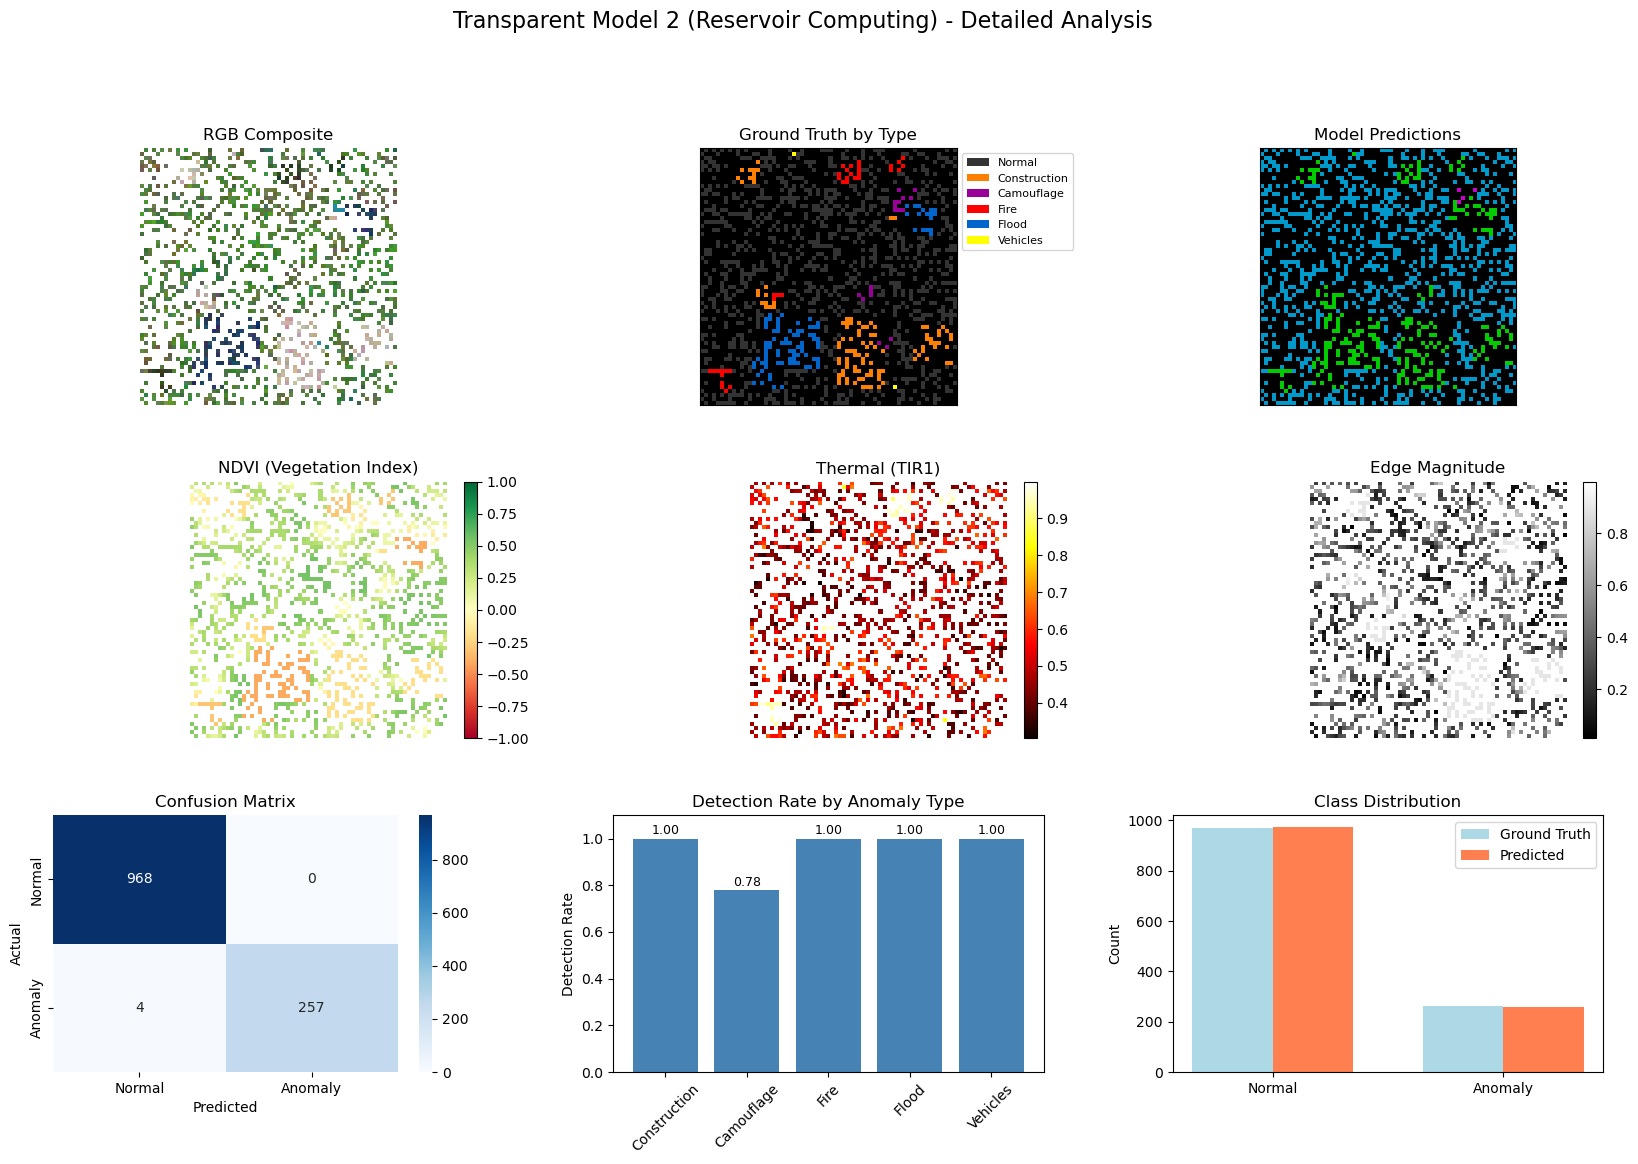

In [122]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc

def main_combined():
    """
    Main demonstration comparing black box and transparent models
    on realistic synthetic satellite imagery for defense/disaster response.
    """
    
    # Generate realistic synthetic satellite data
    print("=" * 60)
    print("GENERATING REALISTIC SATELLITE IMAGERY")
    print("=" * 60)
    print("\nSimulating 64x64 grid with:")
    print("  - 12 spectral/spatial features")
    print("  - 5 anomaly types (construction, camouflage, fires, floods, vehicles)")
    print("  - Spatially correlated terrain")
    print("  - Realistic spectral signatures")
    
    df, X, y, feature_names = generate_realistic_satellite_data(grid_size=64)
    
    print(f"\nGenerated {len(df)} pixels")
    print(f"Total anomalies: {y.sum()} ({100*y.sum()/len(y):.1f}%)")
    print(f"\nAnomaly breakdown:")
    anomaly_types = ['Construction', 'Camouflage', 'Fire', 'Flood', 'Vehicles']
    for i in range(1, 6):
        count = (df['anomaly_type'] == i).sum()
        print(f"  {anomaly_types[i-1]}: {count} pixels")
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, np.arange(len(X)), test_size=0.3, random_state=42, stratify=y
    )
    
    # Create test dataframe for visualization
    df_test = df.iloc[indices_test].copy().reset_index(drop=True)
    
    # For autoencoder, train only on normal data
    X_train_normal = X_train[y_train == 0]
    
    print(f"\nTraining set: {len(X_train)} pixels ({(y_train==0).sum()} normal, {(y_train==1).sum()} anomalies)")
    print(f"Test set: {len(X_test)} pixels ({(y_test==0).sum()} normal, {(y_test==1).sum()} anomalies)")
    
    # ========================================================================
    # TRAIN BLACK BOX MODEL (Autoencoder)
    # ========================================================================
    print("\n" + "=" * 60)
    print("TRAINING BLACK BOX MODEL (Autoencoder)")
    print("=" * 60)
    
    autoencoder, encoder, ae_pred, mse, threshold, ae_accuracy, ae_scaler, history = build_black_box(
        X_train_normal, X_test, y_test
    )
    
    print(f"Black Box Accuracy: {ae_accuracy:.4f}")
    print(f"Threshold: {threshold:.4f}")
    
    # ========================================================================
    # TRAIN TRANSPARENT MODEL 1 (Decision Tree)
    # ========================================================================
    print("\n" + "=" * 60)
    print("TRAINING TRANSPARENT MODEL 1 (Decision Tree)")
    print("=" * 60)
    
    dt_model, dt_pred, dt_accuracy = train_transparent_model(
        X_train, y_train, X_test, y_test, feature_names
    )
    
    print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
    
    # ========================================================================
    # TRAIN TRANSPARENT MODEL 2 (Reservoir Computing)
    # ========================================================================
    print("\n" + "=" * 60)
    print("TRAINING TRANSPARENT MODEL 2 (Reservoir Computing)")
    print("=" * 60)
    
    rc_model, rc_pred, rc_accuracy, rc_scaler, feature_importance = train_reservoir_model(
        X_train, y_train, X_test, y_test, feature_names
    )
    
    print(f"Reservoir Computing Accuracy: {rc_accuracy:.4f}")
    
    # ========================================================================
    # CALCULATE ROC CURVES
    # ========================================================================
    print("\n" + "=" * 60)
    print("CALCULATING PERFORMANCE METRICS")
    print("=" * 60)
    
    # Autoencoder
    fpr_ae, tpr_ae, _ = roc_curve(y_test, mse)
    roc_auc_ae = auc(fpr_ae, tpr_ae)
    
    # Decision tree
    dt_proba = dt_model.predict_proba(X_test)[:, 1]
    fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
    roc_auc_dt = auc(fpr_dt, tpr_dt)
    
    # Reservoir computing
    rc_proba = rc_model.predict_proba(rc_scaler.transform(X_test))[:, 1]
    fpr_rc, tpr_rc, _ = roc_curve(y_test, rc_proba)
    roc_auc_rc = auc(fpr_rc, tpr_rc)
    
    print(f"AUC-ROC Scores:")
    print(f"  Black Box (Autoencoder): {roc_auc_ae:.4f}")
    print(f"  Decision Tree:           {roc_auc_dt:.4f}")
    print(f"  Reservoir Computing:     {roc_auc_rc:.4f}")
    
    # ========================================================================
    # VISUALIZATION 1: Spectral Band Overview
    # ========================================================================
    print("\n" + "=" * 60)
    print("CREATING VISUALIZATIONS")
    print("=" * 60)
    
    print("\n1. Spectral bands overview...")
    fig_bands = plot_spectral_bands(df_test)
    plt.savefig("spectral_bands.png", dpi=300, bbox_inches='tight')
    print("   Saved: spectral_bands.png")
    plt.close()
    
    # ========================================================================
    # VISUALIZATION 2: RGB and False Color Composites
    # ========================================================================
    print("2. RGB and false-color composites...")
    fig_rgb = plot_rgb_composite(df_test)
    plt.savefig("rgb_composites.png", dpi=300, bbox_inches='tight')
    print("   Saved: rgb_composites.png")
    plt.close()
    
    # ========================================================================
    # VISUALIZATION 3: Model Comparison Grid
    # ========================================================================
    print("3. Model predictions comparison...")
    fig = plt.figure(figsize=(24, 6))
    
    ax1 = plt.subplot(1, 4, 1)
    plot_realistic_satellite_data(df_test, "Ground Truth\n(by Anomaly Type)", 
                                 ax=ax1, show_type=True)
    
    ax2 = plt.subplot(1, 4, 2)
    plot_realistic_satellite_data(df_test, f"Autoencoder\nAcc: {ae_accuracy:.3f} | AUC: {roc_auc_ae:.3f}",
                                 predictions=ae_pred, ax=ax2)
    
    ax3 = plt.subplot(1, 4, 3)
    plot_realistic_satellite_data(df_test, f"Decision Tree\nAcc: {dt_accuracy:.3f} | AUC: {roc_auc_dt:.3f}",
                                 predictions=dt_pred, ax=ax3)
    
    ax4 = plt.subplot(1, 4, 4)
    plot_realistic_satellite_data(df_test, f"Reservoir Computing\nAcc: {rc_accuracy:.3f} | AUC: {roc_auc_rc:.3f}",
                                 predictions=rc_pred, ax=ax4)
    
    plt.tight_layout()
    plt.savefig("model_predictions_comparison.png", dpi=300, bbox_inches='tight')
    print("   Saved: model_predictions_comparison.png")
    plt.close()
    
    # ========================================================================
    # VISUALIZATION 4: Detailed Analysis for Each Model
    # ========================================================================
    print("4. Detailed analysis plots...")
    
    # Autoencoder details
    fig_ae = plot_anomaly_detection_details(df_test, ae_pred, y_test)
    fig_ae.suptitle("Black Box Model (Autoencoder) - Detailed Analysis", fontsize=16, y=0.995)
    plt.savefig("autoencoder_details.png", dpi=300, bbox_inches='tight')
    print("   Saved: autoencoder_details.png")
    plt.close()
    
    # Decision Tree details
    fig_dt = plot_anomaly_detection_details(df_test, dt_pred, y_test)
    fig_dt.suptitle("Transparent Model 1 (Decision Tree) - Detailed Analysis", fontsize=16, y=0.995)
    plt.savefig("decision_tree_details.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    # Reservoir Computing details
    fig_rc = plot_anomaly_detection_details(df_test, rc_pred, y_test)
    fig_rc.suptitle("Transparent Model 2 (Reservoir Computing) - Detailed Analysis", fontsize=16, y=0.995)
    plt.savefig("reservoir_details.png", dpi=300, bbox_inches='tight')
    print("   Saved: decision_tree_details.png")
    print("   Saved: reservoir_details.png")
    
    # ========================================================================
    # VISUALIZATION 5: ROC Curves and Feature Importance
    # ========================================================================
    print("5. Performance metrics and interpretability...")
    fig = plt.figure(figsize=(20, 10))
    
    # ROC curves
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC={roc_auc_ae:.3f})', linewidth=2)
    ax1.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_auc_dt:.3f})', linewidth=2)
    ax1.plot(fpr_rc, tpr_rc, label=f'Reservoir (AUC={roc_auc_rc:.3f})', linewidth=2)
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax1.set_xlabel('False Positive Rate', fontsize=11)
    ax1.set_ylabel('True Positive Rate', fontsize=11)
    ax1.set_title('ROC Curves - Model Comparison', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Autoencoder learning curve
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Mean Squared Error', fontsize=11)
    ax2.set_title('Autoencoder Training Progress', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Reconstruction error distribution
    ax3 = plt.subplot(2, 3, 3)
    ax3.hist(mse[y_test == 0], bins=30, alpha=0.6, label='Normal', color='blue', edgecolor='black')
    ax3.hist(mse[y_test == 1], bins=30, alpha=0.6, label='Anomaly', color='red', edgecolor='black')
    ax3.axvline(threshold, color='k', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
    ax3.set_xlabel('Reconstruction Error', fontsize=11)
    ax3.set_ylabel('Count', fontsize=11)
    ax3.set_title('Autoencoder: Reconstruction Error Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Feature importance comparison
    ax4 = plt.subplot(2, 3, 4)
    importances_dt = dt_model.feature_importances_
    importances_rc = np.array([feature_importance[name] for name in feature_names])
    
    x = np.arange(len(feature_names))
    width = 0.35
    
    ax4.bar(x - width/2, importances_dt, width, label='Decision Tree', color='steelblue', edgecolor='black')
    ax4.bar(x + width/2, importances_rc, width, label='Reservoir Computing', color='coral', edgecolor='black')
    
    ax4.set_ylabel('Importance', fontsize=11)
    ax4.set_title('Feature Importance Comparison', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=9)
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Accuracy comparison bar chart
    ax5 = plt.subplot(2, 3, 5)
    models = ['Autoencoder', 'Decision\nTree', 'Reservoir\nComputing']
    accuracies = [ae_accuracy, dt_accuracy, rc_accuracy]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    bars = ax5.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
    ax5.set_ylabel('Accuracy', fontsize=11)
    ax5.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
    ax5.set_ylim(0, 1.0)
    ax5.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, acc) in enumerate(zip(bars, accuracies)):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Decision tree visualization (simplified)
    ax6 = plt.subplot(2, 3, 6)
    from sklearn.tree import plot_tree
    plot_tree(dt_model, filled=True, feature_names=feature_names,
             class_names=["Normal", "Anomaly"], rounded=True, ax=ax6,
             fontsize=7, max_depth=3)
    ax6.set_title("Decision Tree (depth=3)", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig("performance_metrics.png", dpi=300, bbox_inches='tight')
    print("   Saved: performance_metrics.png")
    plt.close()
    
    # ========================================================================
    # EXPLAINABILITY DEMONSTRATION
    # ========================================================================
    print("\n" + "=" * 60)
    print("EXPLAINABILITY COMPARISON")
    print("=" * 60)
    
    # Find a good anomaly sample to explain
    anomaly_indices = np.where(y_test == 1)[0]
    if len(anomaly_indices) > 0:
        # Pick one of each type if possible
        sample_idx = anomaly_indices[0]
        sample_type = df_test.iloc[sample_idx]['anomaly_type']
    else:
        sample_idx = 0
        sample_type = 0
    
    sample_features = X_test[sample_idx]
    sample_label = y_test[sample_idx]
    
    print(f"\nExplaining Sample #{sample_idx}")
    print(f"True Label: {'ANOMALY' if sample_label == 1 else 'NORMAL'}")
    if sample_type > 0:
        print(f"Anomaly Type: {anomaly_types[int(sample_type)-1]}")
    
    print(f"\nFeature Values:")
    for i, name in enumerate(feature_names):
        print(f"  {name:18s}: {sample_features[i]:.3f}")
    
    # Black Box Explanation
    print("\n" + "-" * 60)
    print("1. BLACK BOX MODEL (Autoencoder)")
    print("-" * 60)
    sample_scaled = ae_scaler.transform(sample_features.reshape(1, -1))
    sample_recon = autoencoder.predict(sample_scaled, verbose=0)
    sample_err = np.mean(np.square(sample_scaled - sample_recon))
    
    print(f"Reconstruction Error: {sample_err:.4f}")
    print(f"Threshold:            {threshold:.4f}")
    print(f"Decision:             {'ANOMALY' if sample_err > threshold else 'NORMAL'}")
    print("\n⚠️  NO EXPLANATION: The model cannot explain WHY this classification")
    print("    was made. It's a black box - we only see the error value.")
    
    # Decision Tree Explanation
    print("\n" + "-" * 60)
    print("2. TRANSPARENT MODEL 1 (Decision Tree)")
    print("-" * 60)
    decision_path = explain_transparent_prediction(dt_model, sample_features, feature_names)
    print("Decision Path:")
    for step in decision_path:
        print(f"  {step}")
    print("\n✓ CLEAR EXPLANATION: We can see exactly which rules were applied")
    print("  and why the decision was made.")
    
    # Reservoir Computing Explanation
    print("\n" + "-" * 60)
    print("3. TRANSPARENT MODEL 2 (Reservoir Computing)")
    print("-" * 60)
    rc_sample_scaled = rc_scaler.transform(sample_features.reshape(1, -1))[0]
    explanation = rc_model.explain_prediction(rc_sample_scaled, feature_names)
    
    print(f"Prediction:  {'ANOMALY' if explanation['binary_prediction'] == 1 else 'NORMAL'}")
    print(f"Confidence:  {explanation['prediction']:.4f}")
    print("\nFeature Contributions (sorted by importance):")
    
    sorted_contributions = sorted(explanation['feature_contributions'].items(),
                                 key=lambda x: abs(x[1]), reverse=True)
    for feature, contribution in sorted_contributions:
        bar_length = int(abs(contribution) * 40)
        bar = '█' * bar_length
        print(f"  {feature:18s}: {contribution:+.4f} {bar}")
    
    print("\n✓ FEATURE-LEVEL EXPLANATION: We can see which features contributed")
    print("  most to the decision and by how much.")
    
    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    print("\n" + "=" * 60)
    print("SUMMARY: BLACK BOX vs TRANSPARENT MODELS")
    print("=" * 60)
    
    print("\n📊 PERFORMANCE COMPARISON:")
    print(f"  Autoencoder (Black Box):  Acc={ae_accuracy:.3f}, AUC={roc_auc_ae:.3f}")
    print(f"  Decision Tree:            Acc={dt_accuracy:.3f}, AUC={roc_auc_dt:.3f}")
    print(f"  Reservoir Computing:      Acc={rc_accuracy:.3f}, AUC={roc_auc_rc:.3f}")
    
    print("\n🔍 EXPLAINABILITY COMPARISON:")
    print("  ❌ Black Box: No interpretable explanation")
    print("  ✓ Decision Tree: Clear rule-based logic")
    print("  ✓ Reservoir Computing: Feature contribution analysis")
    
    print("\n💡 KEY INSIGHTS FOR DEFENSE/DISASTER RESPONSE:")
    print("  1. Transparent models provide comparable performance to black boxes")
    print("  2. Explainability is critical for:")
    print("     - Building trust with operators")
    print("     - Validating detections before action")
    print("     - Understanding false positives/negatives")
    print("     - Meeting accountability requirements")
    print("  3. Different transparent approaches offer different tradeoffs:")
    print("     - Decision Trees: Simple, interpretable rules")
    print("     - Reservoir Computing: Richer feature interactions")
    
    print("\n📁 Generated Files:")
    print("  - spectral_bands.png")
    print("  - rgb_composites.png")
    print("  - model_predictions_comparison.png")
    print("  - autoencoder_details.png")
    print("  - decision_tree_details.png")
    print("  - reservoir_details.png")
    print("  - performance_metrics.png")
    
    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)

if __name__ == "__main__":
    main_combined()